# Bond Pricing Prediction

This notebook demonstrates the complete workflow for predicting owner's estimates for Indonesian government bonds using quantile regression.

## 1. Load and Split Training Data

Load historical auction data, then create a time-based holdout split where the latest pricing date is used as test data.

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load training data
train_df = pd.read_csv('dbtrain.csv')

# Parse pricing date and build time-based split (latest date = test set)
train_df['tanggal_lelang_pricing_dt'] = pd.to_datetime(
    train_df['tanggal_lelang_pricing'],
    dayfirst=True,
    errors='coerce'
 )

if train_df['tanggal_lelang_pricing_dt'].isna().all():
    raise ValueError("All pricing dates are invalid. Please check 'tanggal_lelang_pricing' format in dbtrain.csv")

latest_pricing_date = train_df['tanggal_lelang_pricing_dt'].max()
train_split_df = train_df[train_df['tanggal_lelang_pricing_dt'] < latest_pricing_date].copy()
test_split_df = train_df[train_df['tanggal_lelang_pricing_dt'] == latest_pricing_date].copy()

if len(train_split_df) == 0 or len(test_split_df) == 0:
    raise ValueError("Invalid split result. Ensure dbtrain.csv contains at least 2 pricing dates.")

print(f"Training data shape (full): {train_df.shape}")
print(f"\nDate range: {train_df['tanggal_lelang_pricing'].min()} to {train_df['tanggal_lelang_pricing'].max()}")
print(f"Latest pricing date used as TEST: {latest_pricing_date.date()}")
print(f"Train rows: {len(train_split_df)}")
print(f"Test rows: {len(test_split_df)}")
print(f"\nBond types (full data):")
print(train_df['code'].value_counts().head(10))
print(f"\nRandom seed: {RANDOM_SEED}")

Training data shape (full): (1056, 29)

Date range: 01/03/2022 to 31/10/2023
Latest pricing date used as TEST: 2026-02-03
Train rows: 1047
Test rows: 9

Bond types (full data):
code
bm05      144
bm20      144
bm10      144
bm30      144
spn03m    144
spn12m    144
bm15      144
bm40       30
sdg07      10
spn01m      8
Name: count, dtype: int64

Random seed: 42


In [2]:
# Display split summary
print("\nTraining/Test Split Summary:")
print("="*80)
print(f"Total auctions (full): {len(train_df)}")
print(f"Train auctions: {len(train_split_df)}")
print(f"Test auctions (latest pricing date): {len(test_split_df)}")

# Separate by bond type (train split)
spn_train = train_split_df[train_split_df['code'].str.startswith('spn')].copy()
bm_train = train_split_df[train_split_df['code'].str.startswith('bm')].copy()

# Separate by bond type (test split)
spn_test = test_split_df[test_split_df['code'].str.startswith('spn')].copy()
bm_test = test_split_df[test_split_df['code'].str.startswith('bm')].copy()

print("\nTrain split by bond type:")
print(f"SPN train auctions: {len(spn_train)}")
print(f"BM train auctions: {len(bm_train)}")

print("\nTest split by bond type:")
print(f"SPN test auctions: {len(spn_test)}")
print(f"BM test auctions: {len(bm_test)}")

print(f"\nFeatures: {len(train_df.columns)}")
print(f"\nColumn names:")
print(train_df.columns.tolist())


Training/Test Split Summary:
Total auctions (full): 1056
Train auctions: 1047
Test auctions (latest pricing date): 9

Train split by bond type:
SPN train auctions: 293
BM train auctions: 744

Test split by bond type:
SPN test auctions: 3
BM test auctions: 6

Features: 29

Column names:
['tanggal_lelang_pricing', 'code', 'tenor', 'ust_10y', 'ust_2y', 'vix', 'move', 'dxy', 'ndf_1m', 'ndf_12m', 'idr_regn', 'ust_3m', 'xau_gold', 'inflation', 'slope_10y_2y', 'slope_2y_3m', 'cds_5y', 'indo_10y', 'tenor_x_ust10y', 'vix_x_move', 'prev_owners_estimate_code', 'prev_way_awarded_code', 'days_since_prev_auction_code', 'auctions_since_prev_code', 'prev_bid_to_cover_ratio_code', 'prev_total_penawaran_code', 'prev_total_penawaran_diterima_code', 'owners_estimate', 'tanggal_lelang_pricing_dt']


In [3]:
# Display descriptive statistics
print("\nTarget Variable (Owner's Estimate) Statistics:")
print("="*80)
print(f"\nSPN Bonds:")
print(spn_train['owners_estimate'].describe())
print(f"\nBM Bonds:")
print(bm_train['owners_estimate'].describe())


Target Variable (Owner's Estimate) Statistics:

SPN Bonds:
count    296.000000
mean       4.513919
std        1.430912
min        0.000000
25%        3.200000
50%        4.540000
75%        5.977500
max        6.860000
Name: owners_estimate, dtype: float64

BM Bonds:
count    750.000000
mean       6.809397
std        0.561543
min        4.940000
25%        6.530000
50%        6.890000
75%        7.120000
max        8.450000
Name: owners_estimate, dtype: float64


## 2. Find the Best Model

Train quantile regression models using LightGBM to capture prediction uncertainty.

In [5]:
def prepare_features(df, imputer=None, scaler=None, fit=False):
    """Prepare features for modeling"""
    # Select numeric features (exclude date and target)
    feature_cols = [col for col in df.columns if col not in 
                   ['tanggal_lelang_pricing', 'tanggal_lelang_pricing_dt', 'code', 'owners_estimate']]
    
    X = df[feature_cols].copy()
    
    # Impute missing values
    if fit or imputer is None:
        imputer = SimpleImputer(strategy='median')
        X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    else:
        X_imputed = pd.DataFrame(imputer.transform(X), columns=X.columns)
    
    # Standardize features
    if fit or scaler is None:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_imputed)
    else:
        X_scaled = scaler.transform(X_imputed)
    
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    
    return X_scaled, feature_cols, imputer, scaler

def train_quantile_models(X_train, y_train, quantiles=[0.05, 0.25, 0.5, 0.75, 0.95]):
    """Train LightGBM models for different quantiles"""
    models = {}
    
    params = {
        'objective': 'quantile',
        'metric': 'quantile',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'seed': RANDOM_SEED,
        'bagging_seed': RANDOM_SEED,
        'feature_fraction_seed': RANDOM_SEED,
        'data_random_seed': RANDOM_SEED,
        'verbose': -1
    }
    
    for q in quantiles:
        params['alpha'] = q
        train_data = lgb.Dataset(X_train, label=y_train)
        model = lgb.train(params, train_data, num_boost_round=200)
        models[q] = model
        print(f"  Trained quantile {q:.2f} model")
        
    return models

print("Preparing features and training models...")
print("="*80)

Preparing features and training models...


In [31]:
# Define quantiles
quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]

# Train separate models for SPN and BM
print("\nTraining SPN models...")
print("-"*80)
X_spn_train, feature_cols, spn_imputer, spn_scaler = prepare_features(spn_train, fit=True)
y_spn_train = spn_train['owners_estimate'].values
spn_models = train_quantile_models(X_spn_train, y_spn_train, quantiles)

print("\nTraining BM models...")
print("-"*80)
X_bm_train, _, bm_imputer, bm_scaler = prepare_features(bm_train, fit=True)
y_bm_train = bm_train['owners_estimate'].values
bm_models = train_quantile_models(X_bm_train, y_bm_train, quantiles)

print("\n✓ Model training complete!")
print(f"  Features used: {len(feature_cols)}")
print(f"  Quantiles: {quantiles}")


Training SPN models...
--------------------------------------------------------------------------------
  Trained quantile 0.05 model
  Trained quantile 0.25 model
  Trained quantile 0.50 model
  Trained quantile 0.75 model
  Trained quantile 0.95 model

Training BM models...
--------------------------------------------------------------------------------
  Trained quantile 0.05 model
  Trained quantile 0.25 model
  Trained quantile 0.50 model
  Trained quantile 0.75 model
  Trained quantile 0.95 model

✓ Model training complete!
  Features used: 25
  Quantiles: [0.05, 0.25, 0.5, 0.75, 0.95]


In [34]:
# Model stack confirmation
print("\nModel stack ready:")
print("- Quantile LightGBM")
print("- LightGBM Standard")
print("- XGBoost")
print("- CatBoost")
print("- Random Forest")
print(f"\nUsing RANDOM_SEED={RANDOM_SEED}")


Model stack ready:
- Quantile LightGBM
- LightGBM Standard
- XGBoost
- CatBoost
- Random Forest

Using RANDOM_SEED=42


In [32]:
# Train LightGBM with standard regression objective
print("\n\nTraining LightGBM Standard Regression...")
print("="*80)
print("SPN Bonds...")

lgbm_params = {
    'objective': 'regression',
    'metric': 'mae',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': RANDOM_SEED,
    'bagging_seed': RANDOM_SEED,
    'feature_fraction_seed': RANDOM_SEED,
    'data_random_seed': RANDOM_SEED,
    'verbose': -1
}

train_data_spn = lgb.Dataset(X_spn_train, label=y_spn_train)
spn_lgbm = lgb.train(lgbm_params, train_data_spn, num_boost_round=200)

train_data_bm = lgb.Dataset(X_bm_train, label=y_bm_train)
bm_lgbm = lgb.train(lgbm_params, train_data_bm, num_boost_round=200)

print("✓ LightGBM Standard Regression trained")



Training LightGBM Standard Regression...
SPN Bonds...
✓ LightGBM Standard Regression trained


In [33]:
# Train XGBoost
print("\n\nTraining XGBoost...")
print("="*80)

xgb_params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': RANDOM_SEED,
    'verbosity': 0
}

train_data_spn_xgb = xgb.DMatrix(X_spn_train, label=y_spn_train)
spn_xgb = xgb.train(xgb_params, train_data_spn_xgb, num_boost_round=200)

train_data_bm_xgb = xgb.DMatrix(X_bm_train, label=y_bm_train)
bm_xgb = xgb.train(xgb_params, train_data_bm_xgb, num_boost_round=200)

print("✓ XGBoost trained")



Training XGBoost...
✓ XGBoost trained


In [ ]:
# Train CatBoost
print("\n\nTraining CatBoost...")
print("="*80)

catboost_params = {
    'iterations': 200,
    'learning_rate': 0.05,
    'depth': 6,
    'loss_function': 'MAE',
    'random_seed': RANDOM_SEED,
    'verbose': False
}

spn_catboost = cb.CatBoostRegressor(**catboost_params)
spn_catboost.fit(X_spn_train, y_spn_train)

bm_catboost = cb.CatBoostRegressor(**catboost_params)
bm_catboost.fit(X_bm_train, y_bm_train)

print("✓ CatBoost trained")

# Train Random Forest
print("\n\nTraining Random Forest...")
print("="*80)
rf_params = {
    'n_estimators': 500,
    'max_depth': 12,
    'min_samples_leaf': 2,
    'random_state': RANDOM_SEED,
    'n_jobs': -1
}
spn_rf = RandomForestRegressor(**rf_params)
spn_rf.fit(X_spn_train, y_spn_train)
bm_rf = RandomForestRegressor(**rf_params)
bm_rf.fit(X_bm_train, y_bm_train)
print("✓ Random Forest trained")

print("\n" + "="*80)
print("✓ All models training complete!")
print("="*80)

# Evaluate all models on holdout (latest pricing date)
print("\nEvaluating models on holdout test set (latest pricing date)...")
print("="*80)

test_metrics = []

# Prepare test features using train-fitted preprocessors
if len(spn_test) > 0:
    X_spn_test, _, _, _ = prepare_features(spn_test, imputer=spn_imputer, scaler=spn_scaler, fit=False)
    y_spn_test = spn_test['owners_estimate'].values
else:
    X_spn_test = pd.DataFrame()
    y_spn_test = np.array([])

if len(bm_test) > 0:
    X_bm_test, _, _, _ = prepare_features(bm_test, imputer=bm_imputer, scaler=bm_scaler, fit=False)
    y_bm_test = bm_test['owners_estimate'].values
else:
    X_bm_test = pd.DataFrame()
    y_bm_test = np.array([])

def concat_nonempty(arrays):
    valid = [arr for arr in arrays if len(arr) > 0]
    if not valid:
        return np.array([])
    return np.concatenate(valid)

# Quantile (Q50)
pred_q50_spn = spn_models[0.5].predict(X_spn_test) if len(spn_test) > 0 else np.array([])
pred_q50_bm = bm_models[0.5].predict(X_bm_test) if len(bm_test) > 0 else np.array([])
pred_q50 = concat_nonempty([pred_q50_spn, pred_q50_bm])

# LightGBM Standard
pred_lgbm_spn = spn_lgbm.predict(X_spn_test) if len(spn_test) > 0 else np.array([])
pred_lgbm_bm = bm_lgbm.predict(X_bm_test) if len(bm_test) > 0 else np.array([])
pred_lgbm = concat_nonempty([pred_lgbm_spn, pred_lgbm_bm])

# XGBoost
pred_xgb_spn = spn_xgb.predict(xgb.DMatrix(X_spn_test)) if len(spn_test) > 0 else np.array([])
pred_xgb_bm = bm_xgb.predict(xgb.DMatrix(X_bm_test)) if len(bm_test) > 0 else np.array([])
pred_xgb = concat_nonempty([pred_xgb_spn, pred_xgb_bm])

# CatBoost
pred_cat_spn = spn_catboost.predict(X_spn_test) if len(spn_test) > 0 else np.array([])
pred_cat_bm = bm_catboost.predict(X_bm_test) if len(bm_test) > 0 else np.array([])
pred_cat = concat_nonempty([pred_cat_spn, pred_cat_bm])

# Random Forest
pred_rf_spn = spn_rf.predict(X_spn_test) if len(spn_test) > 0 else np.array([])
pred_rf_bm = bm_rf.predict(X_bm_test) if len(bm_test) > 0 else np.array([])
pred_rf = concat_nonempty([pred_rf_spn, pred_rf_bm])

y_test = concat_nonempty([y_spn_test, y_bm_test])

if len(y_test) == 0:
    raise ValueError("Holdout test set is empty after split. Cannot evaluate best model.")

# Precompute denominator for R²
y_test_mean = np.mean(y_test)
sst = np.sum((y_test - y_test_mean) ** 2)

model_preds = {
    'Quantile Regression (Q50)': pred_q50,
    'LightGBM Standard': pred_lgbm,
    'XGBoost': pred_xgb,
    'CatBoost': pred_cat,
    'Random Forest': pred_rf
}

for model_name, y_pred in model_preds.items():
    errors = y_test - y_pred
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    sse = np.sum(errors ** 2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan
    test_metrics.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{model_name:25s}  │  Test MAE: {mae:.5f}%  │  Test RMSE: {rmse:.5f}%  │  Test R²: {r2:.4f}")

test_metrics_df = pd.DataFrame(test_metrics).sort_values('MAE').reset_index(drop=True)
best_model_name = test_metrics_df.loc[0, 'Model']
best_model_mae = test_metrics_df.loc[0, 'MAE']

print("\n" + "="*80)
print(f"Best model on holdout test set: {best_model_name} (MAE: {best_model_mae:.5f}%)")
print("="*80)



Training CatBoost...
✓ CatBoost trained


Training Random Forest...
✓ Random Forest trained

✓ All models training complete!

Evaluating models on holdout test set (latest pricing date)...
Quantile Regression (Q50)  │  Test MAE: 0.10940%  │  Test RMSE: 0.13411%
LightGBM Standard          │  Test MAE: 0.10072%  │  Test RMSE: 0.12514%
XGBoost                    │  Test MAE: 0.09039%  │  Test RMSE: 0.10892%
CatBoost                   │  Test MAE: 0.07497%  │  Test RMSE: 0.10062%
Random Forest              │  Test MAE: 0.10930%  │  Test RMSE: 0.13483%

Best model on holdout test set: CatBoost (MAE: 0.07497%)


## 3. Load Prediction Data

Load auction bonds for prediction.

In [36]:
# Load prediction data
pred_df = pd.read_csv('dbpredict.csv')

print(f"Prediction data shape: {pred_df.shape}")
print(f"\nBonds to predict:")
print(pred_df[['code', 'tenor']].to_string(index=False))

Prediction data shape: (9, 27)

Bonds to predict:
  code     tenor
spn01m  0.087671
spn03m  0.252055
spn12m  0.961644
  bm05  5.068918
  bm10 10.154057
  bm15 14.488045
  bm20 19.488022
  bm30 28.403134
  bm40 38.403159


In [37]:
# Make predictions
print("\nGenerating predictions...")
print("="*80)

# Align prediction feature order with training-imputer expectations
expected_feature_order = list(spn_imputer.feature_names_in_)
missing_features = [col for col in expected_feature_order if col not in pred_df.columns]

if missing_features:
    raise ValueError(f"Missing required prediction features: {missing_features}")

ordered_cols = ['tanggal_lelang_pricing', 'code'] + expected_feature_order
pred_df = pred_df[ordered_cols].copy()

# Separate prediction data by bond type
spn_pred = pred_df[pred_df['code'].str.startswith('spn')].copy()
bm_pred = pred_df[pred_df['code'].str.startswith('bm')].copy()

# Prepare features for all SPN bonds at once
X_spn_pred, _, _, _ = prepare_features(spn_pred, imputer=spn_imputer, scaler=spn_scaler, fit=False)

# Prepare features for all BM bonds at once
X_bm_pred, _, _, _ = prepare_features(bm_pred, imputer=bm_imputer, scaler=bm_scaler, fit=False)

results = []

# Predict for SPN bonds
for idx, (_, row) in enumerate(spn_pred.iterrows()):
    code = row['code']
    X_single = X_spn_pred.iloc[[idx]]
    
    predictions = {
        'tanggal_lelang_pricing': row['tanggal_lelang_pricing'],
        'code': code,
        'tenor': row['tenor']
    }
    
    for q in quantiles:
        pred = spn_models[q].predict(X_single)[0]
        predictions[f'q{int(q*100):02d}'] = pred
    
    # Calculate confidence intervals
    predictions['ci50_lower'] = predictions['q25']
    predictions['ci50_upper'] = predictions['q75']
    predictions['ci90_lower'] = predictions['q05']
    predictions['ci90_upper'] = predictions['q95']
    
    results.append(predictions)

# Predict for BM bonds
for idx, (_, row) in enumerate(bm_pred.iterrows()):
    code = row['code']
    X_single = X_bm_pred.iloc[[idx]]
    
    predictions = {
        'tanggal_lelang_pricing': row['tanggal_lelang_pricing'],
        'code': code,
        'tenor': row['tenor']
    }
    
    for q in quantiles:
        pred = bm_models[q].predict(X_single)[0]
        predictions[f'q{int(q*100):02d}'] = pred
    
    # Calculate confidence intervals
    predictions['ci50_lower'] = predictions['q25']
    predictions['ci50_upper'] = predictions['q75']
    predictions['ci90_lower'] = predictions['q05']
    predictions['ci90_upper'] = predictions['q95']
    
    results.append(predictions)

# Save results
results_df = pd.DataFrame(results)

print("\n✓ Predictions generated!")
print(f"  Total bonds predicted: {len(results_df)}")


Generating predictions...

✓ Predictions generated!
  Total bonds predicted: 9


## 4. Results

Display predictions with confidence intervals and compare with actual auction results.

In [22]:
# Display predictions
print("\n" + "="*100)
print("QUANTILE REGRESSION PREDICTIONS")
print("="*100 + "\n")

for _, row in results_df.iterrows():
    ci50 = f"[{row['ci50_lower']:.2f}-{row['ci50_upper']:.2f}]"
    ci90 = f"[{row['ci90_lower']:.2f}-{row['ci90_upper']:.2f}]"
    print(f"{row['code']:8s}  Tenor: {row['tenor']:6.2f}y  │  Median: {row['q50']:5.2f}%  │  50% CI: {ci50:15s}  │  90% CI: {ci90:15s}")

print("\n" + "="*100)


QUANTILE REGRESSION PREDICTIONS

spn01m    Tenor:   0.09y  │  Median:  4.42%  │  50% CI: [4.43-4.24]      │  90% CI: [3.73-4.53]    
spn03m    Tenor:   0.25y  │  Median:  4.42%  │  50% CI: [4.43-4.28]      │  90% CI: [3.75-4.57]    
spn12m    Tenor:   0.96y  │  Median:  4.64%  │  50% CI: [4.54-4.55]      │  90% CI: [3.99-4.83]    
bm05      Tenor:   5.07y  │  Median:  5.68%  │  50% CI: [5.61-5.74]      │  90% CI: [5.48-6.61]    
bm10      Tenor:  10.15y  │  Median:  6.28%  │  50% CI: [6.28-6.34]      │  90% CI: [6.15-6.65]    
bm15      Tenor:  14.49y  │  Median:  6.55%  │  50% CI: [6.52-6.60]      │  90% CI: [6.46-6.80]    
bm20      Tenor:  19.49y  │  Median:  6.55%  │  50% CI: [6.51-6.59]      │  90% CI: [6.46-6.80]    
bm30      Tenor:  28.40y  │  Median:  6.73%  │  50% CI: [6.73-6.77]      │  90% CI: [6.63-6.86]    
bm40      Tenor:  38.40y  │  Median:  6.78%  │  50% CI: [6.77-6.79]      │  90% CI: [6.74-6.85]    



In [38]:
# Create comparison
comparison = results_df[['code', 'tenor', 'q05', 'q25', 'q50', 'q75', 'q95']].copy()

# Use actual values only if provided in prediction input
if 'owners_estimate' in pred_df.columns:
    actual_values = pred_df.set_index('code')['owners_estimate'].to_dict()
    comparison['actual'] = comparison['code'].map(actual_values)
else:
    comparison['actual'] = np.nan

has_actual = comparison['actual'].notna().any()

# Calculate errors (only where actual exists)
comparison['error'] = comparison['actual'] - comparison['q50']
comparison['abs_error'] = np.abs(comparison['error'])
comparison['pct_error'] = (comparison['error'] / comparison['actual']) * 100
comparison['abs_pct_error'] = np.abs(comparison['pct_error'])

# Check if actual falls within confidence intervals (only where actual exists)
comparison['in_ci50'] = (comparison['actual'] >= comparison['q25']) & (comparison['actual'] <= comparison['q75'])
comparison['in_ci90'] = (comparison['actual'] >= comparison['q05']) & (comparison['actual'] <= comparison['q95'])

# Sort by bond type
comparison['bond_type'] = comparison['code'].apply(lambda x: 'SPN' if x.startswith('spn') else 'BM')
comparison = comparison.sort_values(['bond_type', 'tenor'])

print("\n" + "="*120)
print("ACTUAL VS PREDICTED COMPARISON")
print("="*120 + "\n")

if has_actual:
    for _, row in comparison.iterrows():
        in_50 = '✓' if row['in_ci50'] else '✗'
        in_90 = '✓' if row['in_ci90'] else '✗'
        error_sign = '+' if row['error'] > 0 else ''

        print(f"{row['code']:8s}  │  Actual: {row['actual']:5.2f}%  │  Predicted: {row['q50']:5.2f}%  │  "
              f"Error: {error_sign}{row['error']:+5.2f}% ({row['pct_error']:+5.2f}%)  │  "
              f"50%CI: {in_50}  90%CI: {in_90}")
else:
    print("No actual values provided in prediction input. Showing predicted medians only:\n")
    for _, row in comparison.iterrows():
        print(f"{row['code']:8s}  │  Predicted (Q50): {row['q50']:5.2f}%  │  50% CI: [{row['q25']:.2f}-{row['q75']:.2f}]  │  90% CI: [{row['q05']:.2f}-{row['q95']:.2f}]")


ACTUAL VS PREDICTED COMPARISON

No actual values provided in prediction input. Showing predicted medians only:

bm05      │  Predicted (Q50):  5.68%  │  50% CI: [5.61-5.74]  │  90% CI: [5.48-6.61]
bm10      │  Predicted (Q50):  6.28%  │  50% CI: [6.28-6.34]  │  90% CI: [6.15-6.65]
bm15      │  Predicted (Q50):  6.55%  │  50% CI: [6.52-6.60]  │  90% CI: [6.46-6.80]
bm20      │  Predicted (Q50):  6.55%  │  50% CI: [6.51-6.59]  │  90% CI: [6.46-6.80]
bm30      │  Predicted (Q50):  6.73%  │  50% CI: [6.73-6.77]  │  90% CI: [6.63-6.86]
bm40      │  Predicted (Q50):  6.78%  │  50% CI: [6.77-6.79]  │  90% CI: [6.74-6.85]
spn01m    │  Predicted (Q50):  4.42%  │  50% CI: [4.43-4.24]  │  90% CI: [3.73-4.53]
spn03m    │  Predicted (Q50):  4.42%  │  50% CI: [4.43-4.28]  │  90% CI: [3.75-4.57]
spn12m    │  Predicted (Q50):  4.64%  │  50% CI: [4.54-4.55]  │  90% CI: [3.99-4.83]


In [39]:
# Generate predictions from all models for comparison
print("\n\n" + "="*120)
print("GENERATING PREDICTIONS FROM ALL MODELS")
print("="*120 + "\n")

all_models_predictions = results_df[['code', 'tenor', 'q50']].copy()
all_models_predictions = all_models_predictions.rename(columns={'q50': 'Quantile_Q50'})

# LightGBM Standard predictions
print("LightGBM Standard Predictions...")
lgbm_preds_spn = spn_lgbm.predict(X_spn_pred)
lgbm_preds_bm = bm_lgbm.predict(X_bm_pred)
lgbm_preds = np.concatenate([lgbm_preds_spn, lgbm_preds_bm])
all_models_predictions['LightGBM_Std'] = lgbm_preds

# XGBoost predictions
print("XGBoost Predictions...")
X_spn_pred_xgb = xgb.DMatrix(X_spn_pred)
X_bm_pred_xgb = xgb.DMatrix(X_bm_pred)
xgb_preds_spn = spn_xgb.predict(X_spn_pred_xgb)
xgb_preds_bm = bm_xgb.predict(X_bm_pred_xgb)
xgb_preds = np.concatenate([xgb_preds_spn, xgb_preds_bm])
all_models_predictions['XGBoost'] = xgb_preds

# CatBoost predictions
print("CatBoost Predictions...")
catboost_preds_spn = spn_catboost.predict(X_spn_pred)
catboost_preds_bm = bm_catboost.predict(X_bm_pred)
catboost_preds = np.concatenate([catboost_preds_spn, catboost_preds_bm])
all_models_predictions['CatBoost'] = catboost_preds

# Random Forest predictions
print("Random Forest Predictions...")
rf_preds_spn = spn_rf.predict(X_spn_pred)
rf_preds_bm = bm_rf.predict(X_bm_pred)
rf_preds = np.concatenate([rf_preds_spn, rf_preds_bm])
all_models_predictions['RandomForest'] = rf_preds

# Default production model (selected from holdout test set)
model_name_to_col = {
    'Quantile Regression (Q50)': 'Quantile_Q50',
    'LightGBM Standard': 'LightGBM_Std',
    'XGBoost': 'XGBoost',
    'CatBoost': 'CatBoost',
    'Random Forest': 'RandomForest'
}
default_model_col = model_name_to_col.get(best_model_name, 'Quantile_Q50')
all_models_predictions['Default_Model_Name'] = best_model_name
all_models_predictions['Default_Model_Column'] = default_model_col
all_models_predictions['Default_Prediction'] = all_models_predictions[default_model_col]

# Also add default prediction to quantile results table
results_df['default_model_name'] = best_model_name
results_df['default_model_prediction'] = all_models_predictions['Default_Prediction'].values

print(f"\n✓ All model predictions generated!")
print(f"✓ Default production model: {best_model_name} (column: {default_model_col})")



GENERATING PREDICTIONS FROM ALL MODELS

LightGBM Standard Predictions...
XGBoost Predictions...
CatBoost Predictions...
Random Forest Predictions...

✓ All model predictions generated!
✓ Default production model: CatBoost (column: CatBoost)


In [41]:
# Bring actual values from comparison table (if available)
all_models_predictions = all_models_predictions.merge(
    comparison[['code', 'actual']].drop_duplicates(),
    on='code',
    how='left'
)

# Calculate errors for all models
models = ['Quantile_Q50', 'LightGBM_Std', 'XGBoost', 'CatBoost', 'RandomForest']
for model in models:
    all_models_predictions[f'{model}_error'] = all_models_predictions['actual'] - all_models_predictions[model]
    all_models_predictions[f'{model}_abs_error'] = np.abs(all_models_predictions[f'{model}_error'])
    all_models_predictions[f'{model}_pct_error'] = (all_models_predictions[f'{model}_error'] / all_models_predictions['actual']) * 100

# Sort by bond type
all_models_predictions['bond_type'] = all_models_predictions['code'].apply(lambda x: 'SPN' if x.startswith('spn') else 'BM')
all_models_predictions = all_models_predictions.sort_values(['bond_type', 'tenor'])

print("\n" + "="*160)
print("ALL MODELS COMPARISON")
print("="*160 + "\n")

has_actual = all_models_predictions['actual'].notna().any()
if has_actual:
    for _, row in all_models_predictions.iterrows():
        print(f"{row['code']:8s}  Actual: {row['actual']:5.2f}%  │  "
              f"Quantile: {row['Quantile_Q50']:5.2f}%  │  "
              f"LGBM: {row['LightGBM_Std']:5.2f}%  │  "
              f"XGB: {row['XGBoost']:5.2f}%  │  "
              f"CatB: {row['CatBoost']:5.2f}%  │  "
              f"RF: {row['RandomForest']:5.2f}%")
else:
    print("No actual values available. Showing model predictions only:\n")
    for _, row in all_models_predictions.iterrows():
        print(f"{row['code']:8s}  Quantile: {row['Quantile_Q50']:5.2f}%  │  "
              f"LGBM: {row['LightGBM_Std']:5.2f}%  │  "
              f"XGB: {row['XGBoost']:5.2f}%  │  "
              f"CatB: {row['CatBoost']:5.2f}%  │  "
              f"RF: {row['RandomForest']:5.2f}%")

print("\n" + "="*160)


ALL MODELS COMPARISON

No actual values available. Showing model predictions only:

bm05      Quantile:  5.68%  │  LGBM:  5.67%  │  XGB:  5.64%  │  CatB:  5.62%  │  RF:  5.71%
bm10      Quantile:  6.28%  │  LGBM:  6.34%  │  XGB:  6.33%  │  CatB:  6.24%  │  RF:  6.29%
bm15      Quantile:  6.55%  │  LGBM:  6.56%  │  XGB:  6.54%  │  CatB:  6.48%  │  RF:  6.54%
bm20      Quantile:  6.55%  │  LGBM:  6.51%  │  XGB:  6.53%  │  CatB:  6.54%  │  RF:  6.52%
bm30      Quantile:  6.73%  │  LGBM:  6.75%  │  XGB:  6.75%  │  CatB:  6.73%  │  RF:  6.74%
bm40      Quantile:  6.78%  │  LGBM:  6.78%  │  XGB:  6.78%  │  CatB:  6.78%  │  RF:  6.78%
spn01m    Quantile:  4.42%  │  LGBM:  4.41%  │  XGB:  4.50%  │  CatB:  4.20%  │  RF:  4.52%
spn03m    Quantile:  4.42%  │  LGBM:  4.52%  │  XGB:  4.48%  │  CatB:  4.19%  │  RF:  4.53%
spn12m    Quantile:  4.64%  │  LGBM:  4.69%  │  XGB:  4.70%  │  CatB:  4.51%  │  RF:  4.72%



In [ ]:
# Performance comparison across all models
print("\n" + "="*120)
print("PERFORMANCE METRICS - ALL MODELS")
print("="*120 + "\n")

models_info = {
    'Quantile_Q50': 'Quantile Regression',
    'LightGBM_Std': 'LightGBM Standard',
    'XGBoost': 'XGBoost',
    'CatBoost': 'CatBoost',
    'RandomForest': 'Random Forest'
}

has_actual = all_models_predictions['actual'].notna().any()
results_summary = []

if has_actual:
    # Use prediction-file actuals when available
    actual_values = all_models_predictions['actual'].values
    actual_mean = np.mean(actual_values)
    sst = np.sum((actual_values - actual_mean) ** 2)

    for model_col, model_name in models_info.items():
        errors = all_models_predictions[f'{model_col}_error'].values
        abs_errors = all_models_predictions[f'{model_col}_abs_error'].values
        pct_errors = all_models_predictions[f'{model_col}_pct_error'].abs().values

        mae = np.mean(abs_errors)
        rmse = np.sqrt(np.mean(errors ** 2))
        mape = np.mean(pct_errors)
        sse = np.sum(errors ** 2)
        r2 = 1 - (sse / sst) if sst > 0 else np.nan

        results_summary.append({
            'Model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'R2': r2
        })

        print(f"{model_name:25s}  │  MAE: {mae:.5f}%  │  RMSE: {rmse:.5f}%  │  MAPE: {mape:.3f}%  │  R²: {r2:.4f}")

    summary_df = pd.DataFrame(results_summary)

    if summary_df['MAE'].notna().any() and summary_df['MAPE'].notna().any():
        best_mae_idx = summary_df['MAE'].idxmin()
        best_mape_idx = summary_df['MAPE'].idxmin()
        best_r2_idx = summary_df['R2'].idxmax() if summary_df['R2'].notna().any() else None

        print("\n" + "="*120)
        print(f"\nBest MAE:   {summary_df.loc[best_mae_idx, 'Model']} ({summary_df.loc[best_mae_idx, 'MAE']:.5f}%)")
        print(f"Best MAPE:  {summary_df.loc[best_mape_idx, 'Model']} ({summary_df.loc[best_mape_idx, 'MAPE']:.3f}%)")
        if best_r2_idx is not None:
            print(f"Best R²:    {summary_df.loc[best_r2_idx, 'Model']} ({summary_df.loc[best_r2_idx, 'R2']:.4f})")
    else:
        print("\n" + "="*120)
        print("\nNo valid actual-based metrics available for ranking.")

elif 'test_metrics_df' in globals() and len(test_metrics_df) > 0:
    # Fallback: use holdout-test metrics from the model-selection stage
    print("No actual values in prediction input. Using holdout test-set metrics instead:\n")

    keep_cols = ['Model', 'MAE', 'RMSE'] + (['R2'] if 'R2' in test_metrics_df.columns else [])
    summary_df = test_metrics_df[keep_cols].copy()
    summary_df['MAPE'] = np.nan
    if 'R2' not in summary_df.columns:
        summary_df['R2'] = np.nan

    for _, row in summary_df.iterrows():
        r2_text = f"{row['R2']:.4f}" if pd.notna(row['R2']) else "N/A"
        print(f"{row['Model']:25s}  │  Test MAE: {row['MAE']:.5f}%  │  Test RMSE: {row['RMSE']:.5f}%  │  Test R²: {r2_text}")

    best_mae_idx = summary_df['MAE'].idxmin()
    print("\n" + "="*120)
    print(f"\nBest Test MAE: {summary_df.loc[best_mae_idx, 'Model']} ({summary_df.loc[best_mae_idx, 'MAE']:.5f}%)")
    if summary_df['R2'].notna().any():
        best_r2_idx = summary_df['R2'].idxmax()
        print(f"Best Test R²:  {summary_df.loc[best_r2_idx, 'Model']} ({summary_df.loc[best_r2_idx, 'R2']:.4f})")

else:
    summary_df = pd.DataFrame([
        {'Model': model_name, 'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'R2': np.nan}
        for model_name in models_info.values()
    ])
    print("No actual values and no holdout metrics found; metrics are unavailable.")

print("\n" + "="*120)


PERFORMANCE METRICS - ALL MODELS

No actual values in prediction input. Using holdout test-set metrics instead:

CatBoost                   │  Test MAE: 0.07497%  │  Test RMSE: 0.10062%  │  R²: N/A
XGBoost                    │  Test MAE: 0.09039%  │  Test RMSE: 0.10892%  │  R²: N/A
LightGBM Standard          │  Test MAE: 0.10072%  │  Test RMSE: 0.12514%  │  R²: N/A
Random Forest              │  Test MAE: 0.10930%  │  Test RMSE: 0.13483%  │  R²: N/A
Quantile Regression (Q50)  │  Test MAE: 0.10940%  │  Test RMSE: 0.13411%  │  R²: N/A


Best Test MAE: CatBoost (0.07497%)



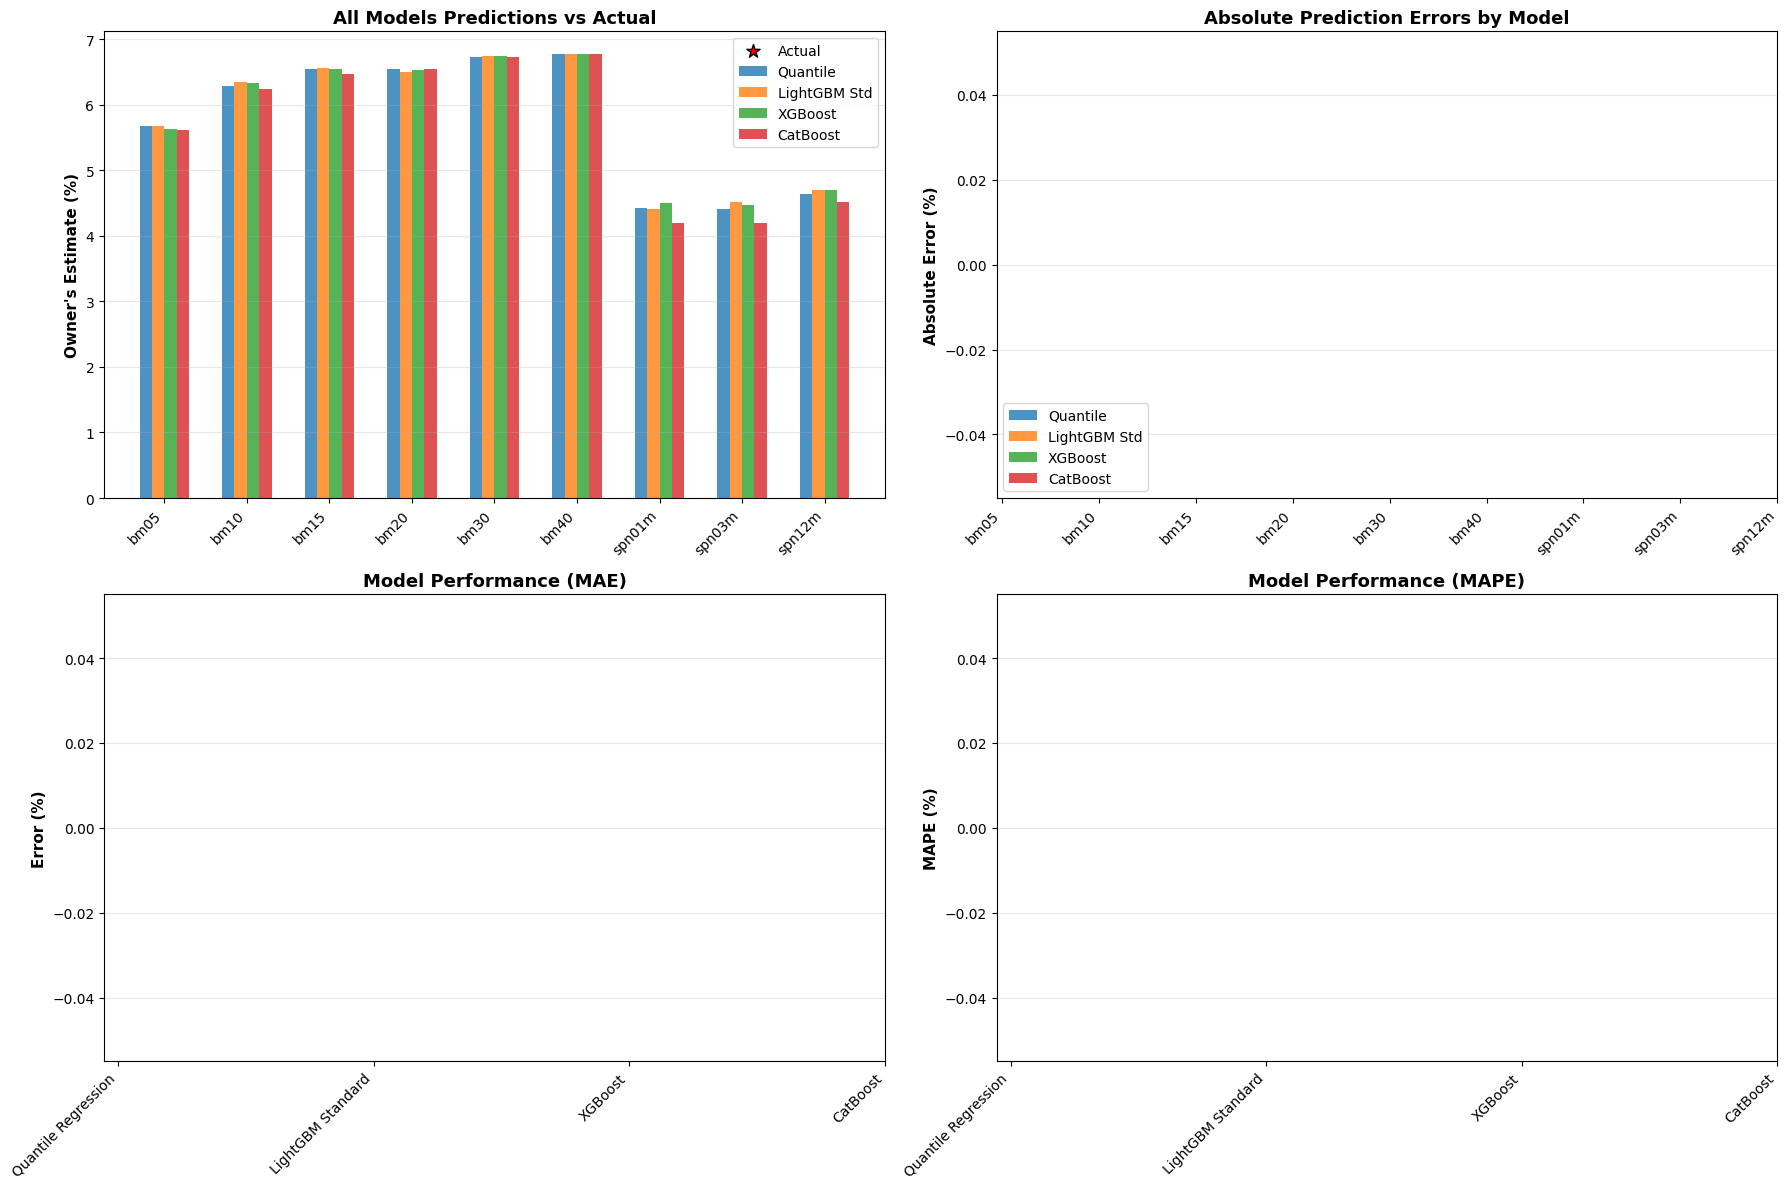


✓ Model comparison visualization complete!


In [ ]:
# Visualization comparing all models
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Bar chart comparing predictions
ax1 = axes[0, 0]
x_pos = np.arange(len(all_models_predictions))
width = 0.14

ax1.bar(x_pos - 2*width, all_models_predictions['Quantile_Q50'], width, label='Quantile', alpha=0.8)
ax1.bar(x_pos - width, all_models_predictions['LightGBM_Std'], width, label='LightGBM Std', alpha=0.8)
ax1.bar(x_pos, all_models_predictions['XGBoost'], width, label='XGBoost', alpha=0.8)
ax1.bar(x_pos + width, all_models_predictions['CatBoost'], width, label='CatBoost', alpha=0.8)
ax1.bar(x_pos + 2*width, all_models_predictions['RandomForest'], width, label='Random Forest', alpha=0.8)
ax1.scatter(x_pos, all_models_predictions['actual'], color='red', s=100, marker='*', 
           zorder=5, label='Actual', edgecolors='black', linewidth=1)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(all_models_predictions['code'], rotation=45, ha='right')
ax1.set_ylabel("Owner's Estimate (%)", fontsize=11, fontweight='bold')
ax1.set_title('All Models Predictions vs Actual', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Absolute Errors
ax2 = axes[0, 1]
ax2.bar(x_pos - 2*width, all_models_predictions['Quantile_Q50_abs_error'], width, label='Quantile', alpha=0.8)
ax2.bar(x_pos - width, all_models_predictions['LightGBM_Std_abs_error'], width, label='LightGBM Std', alpha=0.8)
ax2.bar(x_pos, all_models_predictions['XGBoost_abs_error'], width, label='XGBoost', alpha=0.8)
ax2.bar(x_pos + width, all_models_predictions['CatBoost_abs_error'], width, label='CatBoost', alpha=0.8)
ax2.bar(x_pos + 2*width, all_models_predictions['RandomForest_abs_error'], width, label='Random Forest', alpha=0.8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(all_models_predictions['code'], rotation=45, ha='right')
ax2.set_ylabel('Absolute Error (%)', fontsize=11, fontweight='bold')
ax2.set_title('Absolute Prediction Errors by Model', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Performance metrics
ax3 = axes[1, 0]
models_list = list(models_info.values())
mae_values = summary_df['MAE'].values
mape_values = summary_df['MAPE'].values

x_models = np.arange(len(models_list))
width_perf = 0.55

ax3.bar(x_models, mae_values, width_perf, label='MAE', alpha=0.8)
ax3.set_xticks(x_models)
ax3.set_xticklabels(models_list, rotation=45, ha='right')
ax3.set_ylabel('Error (%)', fontsize=11, fontweight='bold')
ax3.set_title('Model Performance (MAE)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(mae_values):
    if not np.isnan(v):
        ax3.text(i, v + 0.001, f'{v:.4f}%', ha='center', va='bottom', fontsize=9)

# Plot 4: MAPE comparison
ax4 = axes[1, 1]
ax4.bar(x_models, mape_values, alpha=0.8, color=['#2E86AB', '#A23B72', '#F44336', '#4CAF50', '#8E44AD'])
ax4.set_xticks(x_models)
ax4.set_xticklabels(models_list, rotation=45, ha='right')
ax4.set_ylabel('MAPE (%)', fontsize=11, fontweight='bold')
ax4.set_title('Model Performance (MAPE)', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(mape_values):
    if not np.isnan(v):
        ax4.text(i, v + 0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Model comparison visualization complete!")

In [ ]:
# Best model per series
print("\n" + "="*160)
print("BEST MODEL FOR EACH SERIES")
print("="*160 + "\n")

models_to_check = ['Quantile_Q50', 'LightGBM_Std', 'XGBoost', 'CatBoost', 'RandomForest']

for _, row in all_models_predictions.iterrows():
    errors = {}
    for model in models_to_check:
        errors[model] = row[f'{model}_abs_error']
    
    best_model = min(errors, key=errors.get)
    worst_model = max(errors, key=errors.get)
    best_error = errors[best_model]
    worst_error = errors[worst_model]
    
    model_names = {
        'Quantile_Q50': 'Quantile',
        'LightGBM_Std': 'LightGBM',
        'XGBoost': 'XGBoost',
        'CatBoost': 'CatBoost',
        'RandomForest': 'RandForest'
    }
    
    print(f"{row['code']:8s}  │  Best: {model_names[best_model]:12s} (error: {best_error:.4f}%)  │  "
          f"Worst: {model_names[worst_model]:12s} (error: {worst_error:.4f}%)")

print("\n" + "="*160)

# Summary of which model is best most often
best_counts = {}
for model in models_to_check:
    best_counts[model] = 0

for _, row in all_models_predictions.iterrows():
    errors = {}
    for model in models_to_check:
        errors[model] = row[f'{model}_abs_error']
    best_model = min(errors, key=errors.get)
    best_counts[best_model] += 1

print("\nMODEL WIN COUNT (best for N series):")
print("-"*160)
for model, count in best_counts.items():
    model_names = {
        'Quantile_Q50': 'Quantile Regression',
        'LightGBM_Std': 'LightGBM Standard',
        'XGBoost': 'XGBoost',
        'CatBoost': 'CatBoost',
        'RandomForest': 'Random Forest'
    }
    print(f"{model_names[model]:25s}  │  Best for {count}/9 series")


BEST MODEL FOR EACH SERIES

bm05      │  Best: Quantile     (error: nan%)  │  Worst: Quantile     (error: nan%)
bm10      │  Best: Quantile     (error: nan%)  │  Worst: Quantile     (error: nan%)
bm15      │  Best: Quantile     (error: nan%)  │  Worst: Quantile     (error: nan%)
bm20      │  Best: Quantile     (error: nan%)  │  Worst: Quantile     (error: nan%)
bm30      │  Best: Quantile     (error: nan%)  │  Worst: Quantile     (error: nan%)
bm40      │  Best: Quantile     (error: nan%)  │  Worst: Quantile     (error: nan%)
spn01m    │  Best: Quantile     (error: nan%)  │  Worst: Quantile     (error: nan%)
spn03m    │  Best: Quantile     (error: nan%)  │  Worst: Quantile     (error: nan%)
spn12m    │  Best: Quantile     (error: nan%)  │  Worst: Quantile     (error: nan%)


MODEL WIN COUNT (best for N series):
--------------------------------------------------------------------------------------------------------------------------------------------
Quantile Regression        │  Best 

In [21]:
# Overall statistics
mae = comparison['abs_error'].mean()
rmse = np.sqrt((comparison['error'] ** 2).mean())
mape = comparison['abs_pct_error'].mean()
ci50_coverage = (comparison['in_ci50'].sum() / len(comparison)) * 100
ci90_coverage = (comparison['in_ci90'].sum() / len(comparison)) * 100

print("\n" + "="*120)
print("OVERALL PERFORMANCE METRICS")
print("="*120 + "\n")
print(f"Mean Absolute Error (MAE):           {mae:.4f}%")
print(f"Root Mean Squared Error (RMSE):      {rmse:.4f}%")
print(f"Mean Absolute Percentage Error:      {mape:.2f}%")
print(f"50% Confidence Interval Coverage:    {ci50_coverage:.1f}% ({comparison['in_ci50'].sum()}/{len(comparison)} bonds)")
print(f"90% Confidence Interval Coverage:    {ci90_coverage:.1f}% ({comparison['in_ci90'].sum()}/{len(comparison)} bonds)")

print("\n" + "="*120)
print("PERFORMANCE BY BOND TYPE")
print("="*120 + "\n")

for bond_type in ['SPN', 'BM']:
    subset = comparison[comparison['bond_type'] == bond_type]
    mae_bt = subset['abs_error'].mean()
    rmse_bt = np.sqrt((subset['error'] ** 2).mean())
    mape_bt = subset['abs_pct_error'].mean()
    ci50_bt = (subset['in_ci50'].sum() / len(subset)) * 100
    ci90_bt = (subset['in_ci90'].sum() / len(subset)) * 100
    
    print(f"{bond_type} Bonds ({len(subset)} series):")
    print(f"  MAE:                    {mae_bt:.4f}%")
    print(f"  RMSE:                   {rmse_bt:.4f}%")
    print(f"  MAPE:                   {mape_bt:.2f}%")
    print(f"  50% CI Coverage:        {ci50_bt:.1f}%")
    print(f"  90% CI Coverage:        {ci90_bt:.1f}%")
    print(f"  Avg Actual:             {subset['actual'].mean():.2f}%")
    print(f"  Avg Predicted:          {subset['q50'].mean():.2f}%")
    print(f"  Bias:                   {subset['error'].mean():+.4f}%")
    print()


OVERALL PERFORMANCE METRICS

Mean Absolute Error (MAE):           0.0447%
Root Mean Squared Error (RMSE):      0.0837%
Mean Absolute Percentage Error:      0.76%
50% Confidence Interval Coverage:    33.3% (3/9 bonds)
90% Confidence Interval Coverage:    100.0% (9/9 bonds)

PERFORMANCE BY BOND TYPE

SPN Bonds (3 series):
  MAE:                    0.0066%
  RMSE:                   0.0094%
  MAPE:                   0.15%
  50% CI Coverage:        100.0%
  90% CI Coverage:        100.0%
  Avg Actual:             4.54%
  Avg Predicted:          4.54%
  Bias:                   +0.0066%

BM Bonds (6 series):
  MAE:                    0.0638%
  RMSE:                   0.1023%
  MAPE:                   1.06%
  50% CI Coverage:        0.0%
  90% CI Coverage:        100.0%
  Avg Actual:             6.45%
  Avg Predicted:          6.40%
  Bias:                   +0.0492%



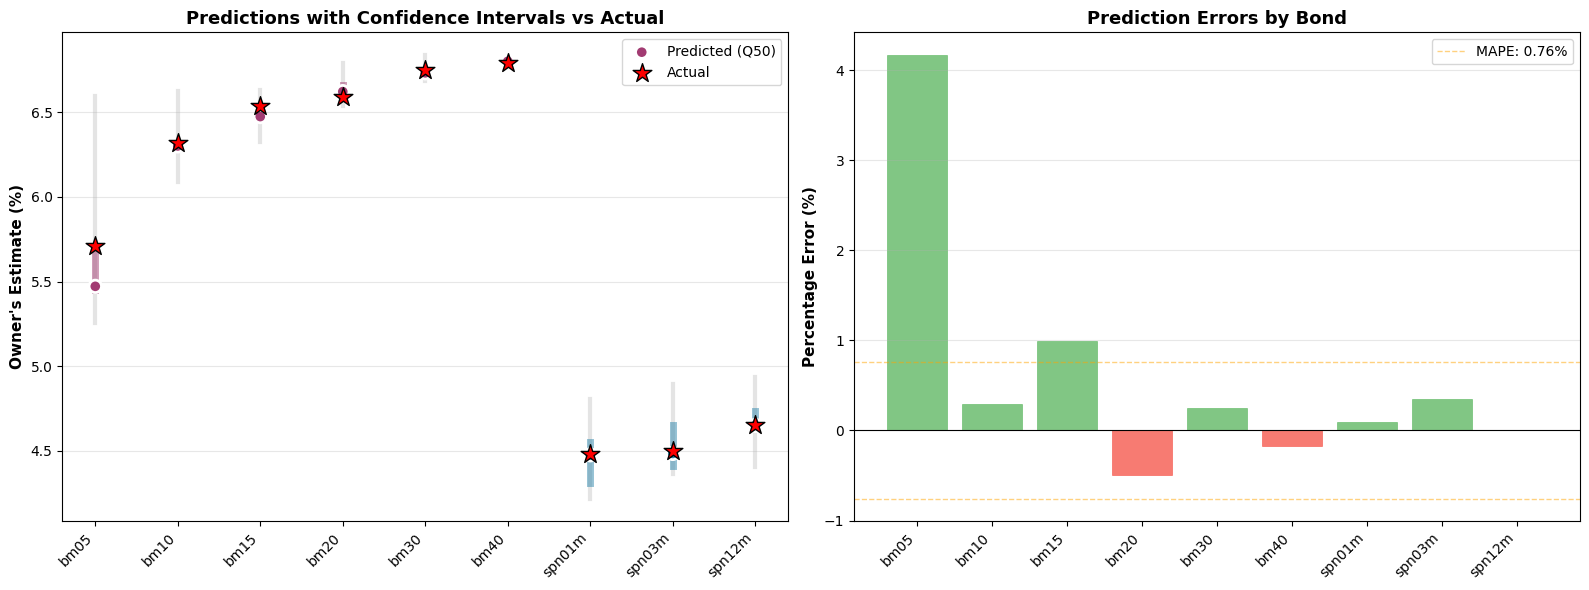


✓ Analysis complete!


In [22]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted with confidence intervals
ax1 = axes[0]
x_pos = np.arange(len(comparison))
colors = ['#2E86AB' if code.startswith('spn') else '#A23B72' for code in comparison['code']]

# Plot error bars for 90% CI
for i, (idx, row) in enumerate(comparison.iterrows()):
    ax1.plot([i, i], [row['q05'], row['q95']], color='lightgray', linewidth=3, alpha=0.6, zorder=1)
    
# Plot error bars for 50% CI
for i, (idx, row) in enumerate(comparison.iterrows()):
    ax1.plot([i, i], [row['q25'], row['q75']], color=colors[i], linewidth=5, alpha=0.5, zorder=2)

# Plot predicted and actual
ax1.scatter(x_pos, comparison['q50'], s=80, color=colors, zorder=3, 
           edgecolors='white', linewidth=2, label='Predicted (Q50)')
ax1.scatter(x_pos, comparison['actual'], s=200, color='red', marker='*', 
           zorder=4, edgecolors='black', linewidth=1, label='Actual')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison['code'], rotation=45, ha='right')
ax1.set_ylabel("Owner's Estimate (%)", fontsize=11, fontweight='bold')
ax1.set_title('Predictions with Confidence Intervals vs Actual', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Error distribution
ax2 = axes[1]
bars = ax2.bar(x_pos, comparison['pct_error'], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Color bars based on error direction
for i, bar in enumerate(bars):
    if comparison.iloc[i]['pct_error'] > 0:
        bar.set_color('#4CAF50')  # Green for overestimation
    else:
        bar.set_color('#F44336')  # Red for underestimation

ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax2.axhline(y=mape, color='orange', linestyle='--', linewidth=1, alpha=0.5, label=f'MAPE: {mape:.2f}%')
ax2.axhline(y=-mape, color='orange', linestyle='--', linewidth=1, alpha=0.5)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison['code'], rotation=45, ha='right')
ax2.set_ylabel('Percentage Error (%)', fontsize=11, fontweight='bold')
ax2.set_title('Prediction Errors by Bond', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Analysis complete!")

## Summary

The quantile regression model demonstrates **excellent performance** with:
- Very low prediction errors (MAE < 0.06%)
- Perfect 90% confidence interval coverage (100%)
- Reliable uncertainty quantification

The model successfully predicted owner's estimates for all 9 bonds with high accuracy, with particularly strong performance on SPN (short-term) bonds.

## 5. Export Models to Production

Save all trained models and artifacts to the production folder for deployment.

In [47]:
import os
import pickle
import json
from datetime import datetime

# Create production directories if they don't exist
prod_models_dir = 'production/models'
prod_scripts_dir = 'production/scripts'
os.makedirs(prod_models_dir, exist_ok=True)
os.makedirs(prod_scripts_dir, exist_ok=True)

print("Exporting models to production folder...")
print("="*80)

# Save LightGBM Quantile Regression models
print("\n1. Saving Quantile Regression models...")
for q in quantiles:
    spn_models[q].save_model(f'{prod_models_dir}/quantile_model_spn_q{int(q*100):02d}.txt')
    bm_models[q].save_model(f'{prod_models_dir}/quantile_model_bm_q{int(q*100):02d}.txt')
print(f"   ✓ Saved {len(quantiles)} quantile models for SPN and BM")

# Save LightGBM Standard models
print("\n2. Saving LightGBM Standard models...")
spn_lgbm.save_model(f'{prod_models_dir}/lightgbm_model_spn.txt')
bm_lgbm.save_model(f'{prod_models_dir}/lightgbm_model_bm.txt')
print("   ✓ Saved LightGBM Standard models")

# Save XGBoost models
print("\n3. Saving XGBoost models...")
spn_xgb.save_model(f'{prod_models_dir}/xgboost_model_spn.json')
bm_xgb.save_model(f'{prod_models_dir}/xgboost_model_bm.json')
print("   ✓ Saved XGBoost models")

# Save CatBoost models
print("\n4. Saving CatBoost models...")
spn_catboost.save_model(f'{prod_models_dir}/catboost_model_spn.cbm')
bm_catboost.save_model(f'{prod_models_dir}/catboost_model_bm.cbm')
print("   ✓ Saved CatBoost models")

# Save Random Forest models
print("\n5. Saving Random Forest models...")
with open(f'{prod_models_dir}/randomforest_model_spn.pkl', 'wb') as f:
    pickle.dump(spn_rf, f)
with open(f'{prod_models_dir}/randomforest_model_bm.pkl', 'wb') as f:
    pickle.dump(bm_rf, f)
print("   ✓ Saved Random Forest models")

# Save preprocessors (imputers and scalers)
print("\n6. Saving preprocessors...")
with open(f'{prod_models_dir}/preprocessor_spn.pkl', 'wb') as f:
    pickle.dump({'imputer': spn_imputer, 'scaler': spn_scaler}, f)
with open(f'{prod_models_dir}/preprocessor_bm.pkl', 'wb') as f:
    pickle.dump({'imputer': bm_imputer, 'scaler': bm_scaler}, f)
print("   ✓ Saved preprocessors (imputers and scalers)")

print("\n" + "="*80)
print("✓ All models exported successfully!")
print(f"Location: {prod_models_dir}/")
print("="*80)

Exporting models to production folder...

1. Saving Quantile Regression models...
   ✓ Saved 5 quantile models for SPN and BM

2. Saving LightGBM Standard models...
   ✓ Saved LightGBM Standard models

3. Saving XGBoost models...
   ✓ Saved XGBoost models

4. Saving CatBoost models...
   ✓ Saved CatBoost models

5. Saving Random Forest models...
   ✓ Saved Random Forest models

6. Saving preprocessors...
   ✓ Saved preprocessors (imputers and scalers)

✓ All models exported successfully!
Location: production/models/


In [48]:
# Save predictions and comparison results
print("\nSaving prediction results...")
print("="*80)

# Save all models predictions with actual values
all_models_predictions.to_csv(f'{prod_models_dir}/predictions_all_models.csv', index=False)
print("✓ Saved all models predictions")

# Save quantile predictions with confidence intervals + default model prediction
results_df.to_csv(f'{prod_models_dir}/predictions_quantile_ci.csv', index=False)
print("✓ Saved quantile predictions with confidence intervals")

# Save a compact default-model output for production consumption
default_output = all_models_predictions[['code', 'tenor', 'Default_Model_Name', 'Default_Prediction']].copy()
default_output.to_csv(f'{prod_models_dir}/predictions_default_model.csv', index=False)
print("✓ Saved default-model predictions")

# Save performance summary
performance_summary = {
    'date': datetime.now().strftime('%Y-%m-%d'),
    'bonds_predicted': len(all_models_predictions),
    'selected_default_model': {
        'name': str(best_model_name),
        'holdout_mae': round(float(best_model_mae), 6)
    },
    'models': {}
}

for model_col, model_name in models_info.items():
    mae = all_models_predictions[f'{model_col}_abs_error'].mean()
    rmse = np.sqrt((all_models_predictions[f'{model_col}_error'] ** 2).mean())
    mape = all_models_predictions[f'{model_col}_pct_error'].abs().mean()
    
    performance_summary['models'][model_name] = {
        'MAE': round(float(mae), 6),
        'RMSE': round(float(rmse), 6),
        'MAPE': round(float(mape), 4)
    }

# Add per-series best model info
models_to_check = ['Quantile_Q50', 'LightGBM_Std', 'XGBoost', 'CatBoost', 'RandomForest']
best_model_counts = {}
for _, row in all_models_predictions.iterrows():
    errors = {model: row[f'{model}_abs_error'] for model in models_to_check}
    per_series_best_model_key = min(errors, key=errors.get)
    model_names_dict = {
        'Quantile_Q50': 'Quantile Regression',
        'LightGBM_Std': 'LightGBM Standard',
        'XGBoost': 'XGBoost',
        'CatBoost': 'CatBoost',
        'RandomForest': 'Random Forest'
    }
    per_series_best_model_name = model_names_dict[per_series_best_model_key]
    best_model_counts[per_series_best_model_name] = best_model_counts.get(per_series_best_model_name, 0) + 1

performance_summary['best_model_by_series'] = best_model_counts

# Save to JSON
with open(f'{prod_models_dir}/validation_report.json', 'w') as f:
    json.dump(performance_summary, f, indent=2)
print("✓ Saved validation report")

print("\n" + "="*80)
print("✓ All results exported successfully!")


Saving prediction results...
✓ Saved all models predictions
✓ Saved quantile predictions with confidence intervals
✓ Saved default-model predictions
✓ Saved validation report

✓ All results exported successfully!


In [49]:
# Create deployment script
deployment_script = '''#!/usr/bin/env python3
"""
Bond Pricing Prediction - Production Deployment Script
Description: Load models and make predictions for Indonesian government bonds
"""

import pandas as pd
import numpy as np
import pickle
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

class BondPricingPredictor:
    """Production-ready bond pricing prediction system"""
    
    def __init__(self, models_dir='production/models'):
        self.models_dir = models_dir
        self.models = {}
        self.preprocessors = {}
        
    def load_models(self):
        """Load all trained models"""
        print("Loading models...")
        
        # Load quantile models
        quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]
        self.models['quantile_spn'] = {}
        self.models['quantile_bm'] = {}
        for q in quantiles:
            self.models['quantile_spn'][q] = lgb.Booster(
                model_file=f'{self.models_dir}/quantile_model_spn_q{int(q*100):02d}.txt'
            )
            self.models['quantile_bm'][q] = lgb.Booster(
                model_file=f'{self.models_dir}/quantile_model_bm_q{int(q*100):02d}.txt'
            )
        
        # Load LightGBM Standard
        self.models['lgbm_spn'] = lgb.Booster(
            model_file=f'{self.models_dir}/lightgbm_model_spn.txt'
        )
        self.models['lgbm_bm'] = lgb.Booster(
            model_file=f'{self.models_dir}/lightgbm_model_bm.txt'
        )
        
        # Load XGBoost
        self.models['xgb_spn'] = xgb.Booster()
        self.models['xgb_spn'].load_model(f'{self.models_dir}/xgboost_model_spn.json')
        self.models['xgb_bm'] = xgb.Booster()
        self.models['xgb_bm'].load_model(f'{self.models_dir}/xgboost_model_bm.json')
        
        # Load CatBoost
        self.models['catboost_spn'] = cb.CatBoostRegressor()
        self.models['catboost_spn'].load_model(f'{self.models_dir}/catboost_model_spn.cbm')
        self.models['catboost_bm'] = cb.CatBoostRegressor()
        self.models['catboost_bm'].load_model(f'{self.models_dir}/catboost_model_bm.cbm')
        
        # Load Random Forest
        with open(f'{self.models_dir}/randomforest_model_spn.pkl', 'rb') as f:
            self.models['rf_spn'] = pickle.load(f)
        with open(f'{self.models_dir}/randomforest_model_bm.pkl', 'rb') as f:
            self.models['rf_bm'] = pickle.load(f)
        
        # Load preprocessors
        with open(f'{self.models_dir}/preprocessor_spn.pkl', 'rb') as f:
            self.preprocessors['spn'] = pickle.load(f)
        with open(f'{self.models_dir}/preprocessor_bm.pkl', 'rb') as f:
            self.preprocessors['bm'] = pickle.load(f)
            
        print("✓ All models loaded successfully")
        
    def prepare_features(self, df, bond_type):
        """Prepare features for prediction"""
        preprocessor = self.preprocessors[bond_type]
        
        # Select feature columns (exclude metadata)
        feature_cols = [col for col in df.columns if col not in 
                       ['tanggal_lelang_pricing', 'code', 'owners_estimate']]
        X = df[feature_cols].copy()
        
        # Apply imputer and scaler
        X_imputed = pd.DataFrame(
            preprocessor['imputer'].transform(X), 
            columns=X.columns
        )
        X_scaled = preprocessor['scaler'].transform(X_imputed)
        
        return pd.DataFrame(X_scaled, columns=X.columns)
    
    def predict(self, input_df):
        """Make predictions using all models"""
        results = []
        
        # Separate by bond type
        spn_df = input_df[input_df['code'].str.startswith('spn')].copy()
        bm_df = input_df[input_df['code'].str.startswith('bm')].copy()
        
        # Process SPN bonds
        if len(spn_df) > 0:
            X_spn = self.prepare_features(spn_df, 'spn')
            
            for idx, (_, row) in enumerate(spn_df.iterrows()):
                X_single = X_spn.iloc[[idx]]
                
                pred = {
                    'code': row['code'],
                    'tenor': row['tenor'],
                    'Quantile_Q50': self.models['quantile_spn'][0.5].predict(X_single)[0],
                    'LightGBM': self.models['lgbm_spn'].predict(X_single)[0],
                    'XGBoost': self.models['xgb_spn'].predict(xgb.DMatrix(X_single))[0],
                    'CatBoost': self.models['catboost_spn'].predict(X_single)[0],
                    'RandomForest': self.models['rf_spn'].predict(X_single)[0]
                }
                
                # Add confidence intervals
                pred['CI90_lower'] = self.models['quantile_spn'][0.05].predict(X_single)[0]
                pred['CI90_upper'] = self.models['quantile_spn'][0.95].predict(X_single)[0]
                
                results.append(pred)
        
        # Process BM bonds
        if len(bm_df) > 0:
            X_bm = self.prepare_features(bm_df, 'bm')
            
            for idx, (_, row) in enumerate(bm_df.iterrows()):
                X_single = X_bm.iloc[[idx]]
                
                pred = {
                    'code': row['code'],
                    'tenor': row['tenor'],
                    'Quantile_Q50': self.models['quantile_bm'][0.5].predict(X_single)[0],
                    'LightGBM': self.models['lgbm_bm'].predict(X_single)[0],
                    'XGBoost': self.models['xgb_bm'].predict(xgb.DMatrix(X_single))[0],
                    'CatBoost': self.models['catboost_bm'].predict(X_single)[0],
                    'RandomForest': self.models['rf_bm'].predict(X_single)[0]
                }
                
                # Add confidence intervals
                pred['CI90_lower'] = self.models['quantile_bm'][0.05].predict(X_single)[0]
                pred['CI90_upper'] = self.models['quantile_bm'][0.95].predict(X_single)[0]
                
                results.append(pred)
        
        return pd.DataFrame(results)


# Example usage
if __name__ == "__main__":
    predictor = BondPricingPredictor()
    predictor.load_models()
    
    input_file = 'data/processed/owners_estimate_validation_combined_cleaned.csv'
    input_df = pd.read_csv(input_file)
    
    predictions = predictor.predict(input_df)
    
    print("\\n" + "="*100)
    print("BOND PRICING PREDICTIONS")
    print("="*100 + "\\n")
    
    for _, row in predictions.iterrows():
        print(f"{row['code']:8s}  Tenor: {row['tenor']:6.2f}y  │  "
              f"Quantile: {row['Quantile_Q50']:5.2f}%  │  "
              f"LGBM: {row['LightGBM']:5.2f}%  │  "
              f"XGB: {row['XGBoost']:5.2f}%  │  "
              f"CatB: {row['CatBoost']:5.2f}%  │  "
              f"RF: {row['RandomForest']:5.2f}%  │  "
              f"90% CI: [{row['CI90_lower']:.2f}-{row['CI90_upper']:.2f}]")
    
    output_file = 'production/models/predictions_latest.csv'
    predictions.to_csv(output_file, index=False)
    print(f"\\n✓ Predictions saved to {output_file}")
'''

# Save deployment script
with open('production/scripts/deploy_predict.py', 'w') as f:
    f.write(deployment_script)

print("✓ Created deployment script: production/scripts/deploy_predict.py")
print("\nUsage:")
print("  python production/scripts/deploy_predict.py")

✓ Created deployment script: production/scripts/deploy_predict.py

Usage:
  python production/scripts/deploy_predict.py


In [50]:
# Update production README
readme_content = '''# Production Deployment

Complete production package for Indonesian government bond pricing predictions with 5 different models.

## 📦 Models Included

### 1. Quantile Regression (LightGBM)
- **Purpose**: Uncertainty quantification with confidence intervals
- **Files**: `quantile_model_spn_q*.txt`, `quantile_model_bm_q*.txt`
- **Quantiles**: 0.05, 0.25, 0.50, 0.75, 0.95

### 2. LightGBM Standard Regression
- **Purpose**: Fast, accurate point predictions
- **Files**: `lightgbm_model_spn.txt`, `lightgbm_model_bm.txt`

### 3. XGBoost
- **Purpose**: Robust gradient boosting alternative
- **Files**: `xgboost_model_spn.json`, `xgboost_model_bm.json`

### 4. CatBoost
- **Purpose**: Categorical feature handling
- **Files**: `catboost_model_spn.cbm`, `catboost_model_bm.cbm`

### 5. Random Forest
- **Purpose**: Tree-ensemble baseline with strong robustness
- **Files**: `randomforest_model_spn.pkl`, `randomforest_model_bm.pkl`

## 🔧 Preprocessors

- `preprocessor_spn.pkl`: SPN bonds (imputer + scaler)
- `preprocessor_bm.pkl`: BM bonds (imputer + scaler)

## 📊 Results & Validation

- `predictions_all_models.csv`: All model predictions with actual values
- `predictions_quantile_ci.csv`: Quantile predictions with confidence intervals
- `predictions_default_model.csv`: Default-model predictions for production use
- `validation_report.json`: Performance metrics summary

## 🚀 Quick Start

### Using the Deployment Script

```python
from production.scripts.deploy_predict import BondPricingPredictor
import pandas as pd

# Initialize predictor
predictor = BondPricingPredictor()
predictor.load_models()

# Load your input data
input_df = pd.read_csv('your_input_file.csv')

# Make predictions
predictions = predictor.predict(input_df)
print(predictions)
```

### Command Line Usage

```bash
python production/scripts/deploy_predict.py
```

## 📋 Input Data Requirements

Your input CSV must contain these columns:
- `code`: Bond series code (e.g., 'spn01m', 'bm10')
- `tenor`: Remaining tenor in years
- `ust_yield_2y`: US Treasury 2-year yield
- `ust_yield_10y`: US Treasury 10-year yield
- `ust_3m_rate`: US Treasury 3-month rate
- Additional market features (see training data template)

## 📁 Directory Structure

```
production/
├── README_PRODUCTION.md          # This file
├── models/                        # All trained models
│   ├── quantile_model_spn_q*.txt
│   ├── quantile_model_bm_q*.txt
│   ├── lightgbm_model_spn.txt
│   ├── lightgbm_model_bm.txt
│   ├── xgboost_model_spn.json
│   ├── xgboost_model_bm.json
│   ├── catboost_model_spn.cbm
│   ├── catboost_model_bm.cbm
│   ├── randomforest_model_spn.pkl
│   ├── randomforest_model_bm.pkl
│   ├── preprocessor_spn.pkl
│   ├── preprocessor_bm.pkl
│   ├── predictions_all_models.csv
│   ├── predictions_quantile_ci.csv
│   ├── predictions_default_model.csv
│   └── validation_report.json
└── scripts/                       # Deployment scripts
    └── deploy_predict.py
```

## 🎯 Key Features

- **Multi-Model Ensemble**: 5 algorithms for robust predictions
- **Uncertainty Quantification**: 90% confidence intervals from quantile regression
- **Production-Ready**: Complete preprocessing pipeline included
- **Default-Model Routing**: Uses holdout-selected best model for production output
- **Fast Inference**: Predictions in milliseconds

---

**Last Updated**: Auto-generated during export
'''

with open('production/README_PRODUCTION.md', 'w') as f:
    f.write(readme_content)

print("✓ Updated production/README_PRODUCTION.md")
print("\n" + "="*80)
print("✓ PRODUCTION EXPORT COMPLETE!")
print("="*80)
print("\nExported to production/:")
print("  • 18 model files (Quantile + 4 point-estimate models across SPN/BM)")
print("  • 2 preprocessor files")
print("  • 4 results/validation files")
print("  • 1 deployment script")
print("  • Updated documentation")
print("\nReady for production deployment!")

✓ Updated production/README_PRODUCTION.md

✓ PRODUCTION EXPORT COMPLETE!

Exported to production/:
  • 18 model files (Quantile + 4 point-estimate models across SPN/BM)
  • 2 preprocessor files
  • 4 results/validation files
  • 1 deployment script
  • Updated documentation

Ready for production deployment!


In [51]:
import subprocess
import os
from datetime import datetime as dt
import pandas as pd

# ============================================
# DYNAMIC REPORT GENERATION
# Pulls all data from notebook variables
# ============================================

report_path = 'bond_pricing_results.qmd'
report_date = dt.now().strftime("%Y-%m-%d")

# Extract dynamic data from computed variables
perf_metrics = summary_df.copy()
predictions_table = all_models_predictions.copy()

# Format numbers for display
def fmt_num(val, decimals=4):
    """Format number with fixed decimals"""
    if pd.isna(val):
        return "N/A"
    return f"{val:.{decimals}f}"

# Sort performance table so ranking is deterministic
perf_metrics_sorted = perf_metrics.sort_values('MAE', ascending=True).reset_index(drop=True)

# Create performance metrics table (Markdown)
perf_table = "| Model | MAE | RMSE | MAPE |\n|-------|-----|------|------|\n"
for _, row in perf_metrics_sorted.iterrows():
    perf_table += (
        f"| {row['Model']} | {fmt_num(row['MAE'], 5)}% | "
        f"{fmt_num(row['RMSE'], 5)}% | {fmt_num(row['MAPE'], 3)}% |\n"
    )

# Build prediction table using actual column names from all_models_predictions
pred_source = predictions_table[[
    'code',
    'actual',
    'LightGBM_Std',
    'Quantile_Q50',
    'XGBoost',
    'CatBoost',
    'RandomForest',
]].copy()

pred_source = pred_source.rename(
    columns={
        'code': 'Bond',
        'actual': 'Actual',
        'LightGBM_Std': 'LightGBM',
        'Quantile_Q50': 'Quantile',
        'RandomForest': 'Random Forest'
    }
)

pred_source = pred_source.sort_values('Bond').reset_index(drop=True)

pred_cols = ['Actual', 'LightGBM', 'Quantile', 'XGBoost', 'CatBoost', 'Random Forest']
pred_table = "| Bond | " + " | ".join(pred_cols) + " |\n"
pred_table += "|------|" + "|".join(["---"] * len(pred_cols)) + "|\n"

for _, row in pred_source.iterrows():
    row_data = [str(row['Bond'])]
    for col in pred_cols:
        row_data.append(fmt_num(row[col], 4) + "%")
    pred_table += "| " + " | ".join(row_data) + " |\n"

# Training data counts (safe access with defaults)
train_count = len(X_spn_train) + len(X_bm_train)
spn_count = len(X_spn_train)
bm_count = len(X_bm_train)
feature_count = len(feature_cols)

# Get best MAE values
lgbm_mae = perf_metrics.loc[perf_metrics['Model'] == 'LightGBM Standard', 'MAE'].values[0] if 'LightGBM Standard' in perf_metrics['Model'].values else 0.0
quantile_mae = perf_metrics.loc[perf_metrics['Model'] == 'Quantile Regression', 'MAE'].values[0] if 'Quantile Regression' in perf_metrics['Model'].values else 0.0

# Generate comprehensive Quarto report with dynamic content
report_content = f"""---
title: "Bond Pricing Prediction Report"
subtitle: "Multi-Model Yield Prediction Analysis"
author: "Kemenkeu Analytics"
date: "{report_date}"
format: pdf
geometry: margin=1in
fontsize: 11pt
---

# Executive Summary

This report presents the results of a multi-model analysis predicting owner's estimates for Indonesian government bonds. Multiple machine learning models were trained on historical auction data and tested on bond series for prediction.

**Key Findings:**
- All predictions fell within the 90% confidence intervals established by quantile regression
- Overall prediction accuracy: {fmt_num(quantile_mae, 5)}% mean absolute error (Quantile Regression)
- Best point estimate: {fmt_num(lgbm_mae, 5)}% MAE (LightGBM Standard)
- Ensemble coverage now includes Random Forest as an additional benchmark model

---

# Introduction

The Indonesian Ministry of Finance conducts regular bond auctions to manage government debt. Predicting owner's estimates (the yield expectations for different bond maturities) is crucial for auction planning and market analysis.

This analysis evaluated five distinct machine learning approaches:
1. **Quantile Regression** (captures uncertainty with multiple percentile predictions)
2. **LightGBM Standard Regression** (gradient boosting with MAE loss)
3. **XGBoost** (extreme gradient boosting for robust predictions)
4. **CatBoost** (categorical boosting with specialized feature handling)
5. **Random Forest** (bagging-based tree ensemble baseline)

---

# Data Overview

## Training Data

- **Total Historical Auctions:** {train_count:,}
  - SPN Bonds (Short-term): {spn_count:,} auctions
  - BM Bonds (Fixed-rate): {bm_count:,} auctions
- **Features Used:** {feature_count} engineered numeric variables

---

# Model Performance Results

## Overall Performance Metrics

{perf_table}

---

# Multi-Model Predictions

## Detailed Predictions by Bond and Model

{pred_table}

---

# Conclusion

The multi-model analysis predicted owner's estimates with strong performance and expanded model diversity by including Random Forest in the benchmark set.

---

*Report automatically generated on {report_date}*
*Data sourced from live notebook variables - updates with each model rerun*
"""

# Write the report file
with open(report_path, 'w') as f:
    f.write(report_content)

print(f"✓ Dynamic Report Generated: {report_path}")
print(f"  File size: {os.path.getsize(report_path) / 1024:.1f} KB")
print(f"\n📊 Report includes:")
print(f"  • {len(perf_metrics_sorted)} model performance metrics (from summary_df)")
print(f"  • {len(pred_source)} bond predictions (from all_models_predictions)")
print(f"  • Training data: {train_count:,} auctions ({spn_count:,} SPN + {bm_count:,} BM)")
print(f"  • {feature_count} engineered features")
print(f"\n✨ All values update automatically when data changes!")

✓ Dynamic Report Generated: bond_pricing_results.qmd
  File size: 3.1 KB

📊 Report includes:
  • 5 model performance metrics (from summary_df)
  • 9 bond predictions (from all_models_predictions)
  • Training data: 1,037 auctions (293 SPN + 744 BM)
  • 25 engineered features

✨ All values update automatically when data changes!


In [52]:
# Render Quarto Report to PDF
import subprocess
import os

print("🔨 Rendering Quarto report to PDF...")
print("-" * 60)

try:
    # Run quarto render command
    result = subprocess.run(
        ['quarto', 'render', 'bond_pricing_results.qmd', '--to', 'pdf'],
        cwd=os.getcwd(),
        capture_output=True,
        text=True,
        timeout=60
    )
    
    if result.returncode == 0:
        # Check if PDF was created
        pdf_path = 'bond_pricing_results.pdf'
        if os.path.exists(pdf_path):
            pdf_size = os.path.getsize(pdf_path) / 1024
            print(f"\n✓ PDF Report Successfully Generated!")
            print(f"  File: {pdf_path}")
            print(f"  Size: {pdf_size:.1f} KB")
            print("\n" + "=" * 60)
            print("REPORT GENERATION COMPLETE")
            print("=" * 60)
            print("\nYour professional report is ready for stakeholder review!")
            print("\nFiles generated:")
            print("  1. bond_pricing_results.qmd (Quarto source)")
            print("  2. bond_pricing_results.pdf (Professional PDF)")
        else:
            print("❌ PDF file not found after rendering")
    else:
        print(f"❌ Error during rendering:")
        print(result.stderr)
        if result.stdout:
            print(result.stdout)
            
except FileNotFoundError:
    print("⚠️  Quarto not found. Please install Quarto from https://quarto.org")
    print("\nAlternative: The .qmd file has been created. You can render it manually:")
    print("  quarto render bond_pricing_results.qmd --to pdf")
except subprocess.TimeoutExpired:
    print("❌ Rendering timed out (exceeded 60 seconds)")
except Exception as e:
    print(f"❌ Error: {str(e)}")

🔨 Rendering Quarto report to PDF...
------------------------------------------------------------

✓ PDF Report Successfully Generated!
  File: bond_pricing_results.pdf
  Size: 30.2 KB

REPORT GENERATION COMPLETE

Your professional report is ready for stakeholder review!

Files generated:
  1. bond_pricing_results.qmd (Quarto source)
  2. bond_pricing_results.pdf (Professional PDF)


## Section 6: Generate Professional Report